# 📓 Notebook 07 — Model Explainability

> ### 🔍 From Stockout Prediction to Stockout Explanation
>
> Now **RetailIQ** moves from:
>
> **“Which products are likely to stock out?”**
>
> to:
>
> **“Why does RetailIQ think this product is likely to stock out?”**
>
> We will use **SHAP (SHapley Additive exPlanations)** to explain the **XGBoost stockout model**.

---

## 🔄 Notebook 07 Flow

```text
Stockout Prediction
        ↓
XGBoost Risk Model
        ↓
SHAP Explainability
        ↓
Global Risk Drivers
        ↓
Individual Product Explanation
        ↓
Business-Friendly Risk Reasons
```

---

## 🎯 What This Notebook Will Do

### 1️⃣ Reproduce the Stockout Model

* 🔁 Reproduce the **refined XGBoost stockout model** from Notebook 06.
* 🧩 Use the same prediction-time features and modeling setup.

### 2️⃣ Apply SHAP Explainability

* 🔍 Introduce **SHAP (SHapley Additive exPlanations)**.
* 🧮 Calculate SHAP values for the XGBoost stockout model.
* 📊 Understand how individual features influence stockout risk.

### 3️⃣ Analyze Global Risk Drivers

* 🌎 Identify the features that have the strongest overall influence on stockout predictions.
* 📈 Visualize the most important stockout risk drivers.
* 🔎 Understand whether features generally push predictions toward **higher** or **lower** stockout risk.

### 4️⃣ Explain Individual Products

* 📦 Select individual product-day predictions.
* 🔍 Examine the features contributing to each prediction.
* 📊 Show which factors increased or decreased the predicted stockout risk.

### 5️⃣ Convert SHAP Results into Business Explanations

Transform technical SHAP outputs into understandable business reasons such as:

```text
High Stockout Risk

Why?
• Current inventory is very low
• Recent demand is unusually high
• Recent sales trend is increasing
• Expected demand is greater than available inventory
```

---

## ⚠️ Important Modeling Principle

> **We will NOT train a completely different model in Notebook 07.**

Instead, we will:

```text
Notebook 06
     │
     ▼
Refined XGBoost Stockout Model
     │
     ▼
Notebook 07
     │
     ▼
Explain the SAME model's predictions
```

This ensures that the explanations correspond to the **actual XGBoost stockout model** used by RetailIQ rather than explanations from a separate replacement model.

---

## 🎯 Final Goal

By the end of **Notebook 07**, RetailIQ should be able to answer two questions:

### 📦 Prediction

> **“Which products are likely to stock out?”**

### 🔍 Explanation

> **“Why does RetailIQ think this product is likely to stock out?”**

The final output should turn **model predictions into actionable, business-friendly stockout risk explanations**.


### Step 1 — Install / Import SHAP
Why

SHAP provides mathematical explanations for individual predictions and overall model behavior.

In [4]:
import shap

print("SHAP version:", shap.__version__)

c:\Users\dhanu\RetailIQ\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.51.0


### Step 2 — Import Libraries
Why

We need data processing, visualization, model training, SHAP, and saving utilities.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

### Step 3 — Load Feature-Engineered Dataset
Why

Notebook 04 contains the historical and inventory features needed by the stockout model.

In [6]:
df = pd.read_csv(
    "../data/processed/feature_engineered_data.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset shape:", df.shape)
print(
    "Date range:",
    df["Date"].min(),
    "to",
    df["Date"].max()
)

Dataset shape: (76000, 40)
Date range: 2022-01-01 00:00:00 to 2024-01-30 00:00:00


### Step 4 — Sort Data Chronologically
Why

All historical calculations and target construction must respect the Store-Product time sequence.

In [7]:
df = df.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

print(
    df[
        ["Store ID", "Product ID", "Date"]
    ].head(10)
)

  Store ID Product ID       Date
0     S001      P0001 2022-01-01
1     S001      P0001 2022-01-02
2     S001      P0001 2022-01-03
3     S001      P0001 2022-01-04
4     S001      P0001 2022-01-05
5     S001      P0001 2022-01-06
6     S001      P0001 2022-01-07
7     S001      P0001 2022-01-08
8     S001      P0001 2022-01-09
9     S001      P0001 2022-01-10


### Step 5 — Create Future Inventory Columns
Why

We need the same stockout definition used in Notebook 06.

In [8]:
group_cols = [
    "Store ID",
    "Product ID"
]

for i in range(1, 8):
    df[f"Inventory_Next_{i}_Day"] = (
        df.groupby(group_cols)["Inventory Level"]
        .shift(-i)
    )

future_inventory_cols = [
    f"Inventory_Next_{i}_Day"
    for i in range(1, 8)
]

### Step 6 — Create Stockout Target
Why

This reproduces the target: stockout occurring at least once during the next seven days.

In [9]:
df["stockout_next_7_days"] = (
    df[future_inventory_cols]
    .eq(0)
    .any(axis=1)
    .astype(int)
)

print(
    df["stockout_next_7_days"]
    .value_counts()
    .sort_index()
)

stockout_next_7_days
0    73476
1     2524
Name: count, dtype: int64


### Step 7 — Remove Future Inventory Columns
Why

Future inventory can be used to create the target, but it must never become a model feature.

In [10]:
df_model = df.drop(
    columns=future_inventory_cols
).copy()

print("Shape:", df_model.shape)

Shape: (76000, 41)


### Step 8 — Define Historical Features
Why

These features must be complete before we train the explainable model.

In [11]:
historical_features = [
    "Demand_Lag_1",
    "Demand_Lag_2",
    "Demand_Lag_7",
    "Demand_Lag_14",
    "Demand_Lag_28",
    "Demand_Rolling_Mean_7",
    "Demand_Rolling_Mean_14",
    "Demand_Rolling_Mean_28",
    "Demand_Rolling_Std_7"
]

df_model = df_model.dropna(
    subset=historical_features
).copy()

print(
    "Final modeling dataset:",
    df_model.shape
)

Final modeling dataset: (73200, 41)


### Step 9 — Define Stockout Features
Why

We must use the same feature set as Notebook 06 so the explanations correspond to the stockout model.

In [12]:
stockout_features = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality",
    "Year",
    "Month",
    "Quarter",
    "Day",
    "DayOfWeek",
    "IsWeekend",
    "Promotion",
    "Discount",
    "Discount_Pct",
    "Price",
    "Competitor Pricing",
    "Price_Difference",
    "Price_Ratio",
    "Epidemic",
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Demand_Lag_1",
    "Demand_Lag_2",
    "Demand_Lag_7",
    "Demand_Lag_14",
    "Demand_Lag_28",
    "Demand_Rolling_Mean_7",
    "Demand_Rolling_Mean_14",
    "Demand_Rolling_Mean_28",
    "Demand_Rolling_Std_7",
    "Demand_Change_1",
    "Demand_Change_7",
    "Inventory_Gap",
    "Inventory_Coverage_Days"
]

target = "stockout_next_7_days"

X = df_model[stockout_features].copy()
y = df_model[target].copy()

print("Features:", X.shape)
print("Target:", y.shape)

Features: (73200, 36)
Target: (73200,)


### Step 10 — Define Time-Based Training Data
Why

Explainability must be based on the same future-testing scenario used in Notebook 06.

In [13]:
validation_end_date = pd.Timestamp(
    "2023-06-30"
)

train_end_date = pd.Timestamp(
    "2023-09-05"
)

train_mask = (
    df_model["Date"] <= validation_end_date
)

validation_mask = (
    (df_model["Date"] > validation_end_date) &
    (df_model["Date"] <= train_end_date)
)

test_mask = (
    df_model["Date"] > train_end_date
)

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_validation = X.loc[validation_mask].copy()
y_validation = y.loc[validation_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

print("Training:", X_train.shape)
print("Validation:", X_validation.shape)
print("Testing:", X_test.shape)

Training: (51800, 36)
Validation: (6700, 36)
Testing: (14700, 36)


### Step 11 — Identify Categorical Features
Why

Categorical variables need one-hot encoding before entering XGBoost.

In [14]:
categorical_features = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

numerical_features = [
    feature
    for feature in stockout_features
    if feature not in categorical_features
]

print(
    "Categorical:",
    len(categorical_features)
)

print(
    "Numerical:",
    len(numerical_features)
)

Categorical: 6
Numerical: 30


### Step 12 — Create Preprocessor
Why

This reproduces the same preprocessing pipeline used by the stockout model.

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

### Step 13 — Calculate Training Class Weight
Why

Stockouts are only about 3% of the data, so XGBoost needs additional weight for the minority class.

In [16]:
class_counts = y_train.value_counts()

negative_count = class_counts.get(0, 0)
positive_count = class_counts.get(1, 0)

scale_pos_weight = (
    negative_count / positive_count
)

print("Negative:", negative_count)
print("Positive:", positive_count)
print(
    "scale_pos_weight:",
    scale_pos_weight
)

Negative: 50113
Positive: 1687
scale_pos_weight: 29.70539419087137


### Step 14 — Create XGBoost Model
Why

We reproduce the refined XGBoost model used for the final stockout-risk predictions.

In [17]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            xgb.XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

### Step 15 — Train XGBoost
Why

We need the trained tree model before SHAP can explain its predictions.

In [19]:
xgb_model.fit(
    X_train,
    y_train
)

print(
    "XGBoost stockout model trained successfully."
)

XGBoost stockout model trained successfully.


### Step 16 — Generate Test Probabilities
Why

These probabilities are the stockout-risk scores that SHAP will explain.

In [20]:
xgb_test_proba = (
    xgb_model
    .predict_proba(X_test)[:, 1]
)

print(
    "Probability range:",
    xgb_test_proba.min(),
    "to",
    xgb_test_proba.max()
)

print(
    "Mean probability:",
    xgb_test_proba.mean()
)

Probability range: 1.6021544e-05 to 0.84608227
Mean probability: 0.042860895


### Step 17 — Apply Notebook 06 Threshold
Why

Notebook 06 selected 0.20 as the XGBoost validation threshold.

In [21]:
xgb_threshold = 0.20

xgb_test_pred = (
    xgb_test_proba >= xgb_threshold
).astype(int)

print(
    "Predicted stockouts:",
    xgb_test_pred.sum()
)

print(
    "Actual stockouts:",
    y_test.sum()
)

Predicted stockouts: 780
Actual stockouts: 491


### Step 18 — Verify Model Performance
Why

We should confirm that the recreated model behaves consistently with Notebook 06.

In [22]:
precision = precision_score(
    y_test,
    xgb_test_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    xgb_test_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    xgb_test_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    xgb_test_proba
)

pr_auc = average_precision_score(
    y_test,
    xgb_test_proba
)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

Precision: 0.10512820512820513
Recall: 0.1670061099796334
F1: 0.12903225806451613
ROC-AUC: 0.7466350104542042
PR-AUC: 0.08422823014749335


### Step 19 — Extract Transformed Feature Names
Why

SHAP needs the actual features used by XGBoost after one-hot encoding.

In [23]:
preprocessor_fitted = (
    xgb_model
    .named_steps["preprocessor"]
)

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

print(
    "Transformed feature count:",
    len(feature_names)
)

print(
    feature_names[:20]
)

Transformed feature count: 72
['categorical__Store ID_S001' 'categorical__Store ID_S002'
 'categorical__Store ID_S003' 'categorical__Store ID_S004'
 'categorical__Store ID_S005' 'categorical__Product ID_P0001'
 'categorical__Product ID_P0002' 'categorical__Product ID_P0003'
 'categorical__Product ID_P0004' 'categorical__Product ID_P0005'
 'categorical__Product ID_P0006' 'categorical__Product ID_P0007'
 'categorical__Product ID_P0008' 'categorical__Product ID_P0009'
 'categorical__Product ID_P0010' 'categorical__Product ID_P0011'
 'categorical__Product ID_P0012' 'categorical__Product ID_P0013'
 'categorical__Product ID_P0014' 'categorical__Product ID_P0015']


### Step 20 — Transform the Test Data
Why

SHAP must explain the exact numerical matrix given to XGBoost.

In [24]:
X_test_transformed = (
    preprocessor_fitted
    .transform(X_test)
)

print(
    "Transformed test shape:",
    X_test_transformed.shape
)

Transformed test shape: (14700, 72)


### Step 21 — Convert to Dense Matrix
Why

A dense matrix makes SHAP analysis and visualization easier.

In [25]:
if hasattr(
    X_test_transformed,
    "toarray"
):
    X_test_shap = (
        X_test_transformed.toarray()
    )
else:
    X_test_shap = X_test_transformed

print(
    "SHAP matrix shape:",
    X_test_shap.shape
)

SHAP matrix shape: (14700, 72)


### Step 22 — Create SHAP Explainer
Why

TreeExplainer is designed specifically for tree-based models such as XGBoost.

In [26]:
xgb_classifier = (
    xgb_model
    .named_steps["classifier"]
)

explainer = shap.TreeExplainer(
    xgb_classifier
)

print(
    "SHAP TreeExplainer created."
)

SHAP TreeExplainer created.


### Step 23 — Calculate SHAP Values
Why

SHAP values tell us how each feature pushes a prediction toward higher or lower stockout risk.

In [27]:
shap_values = explainer.shap_values(
    X_test_shap
)

print(
    "SHAP values shape:",
    shap_values.shape
)

SHAP values shape: (14700, 72)


### Step 24 — Verify SHAP Values
Why

We verify that the SHAP explanation reconstructs the model's prediction score.

In [28]:
print(
    "Expected value:",
    explainer.expected_value
)

print(
    "First SHAP row shape:",
    shap_values[0].shape
)

print(
    "First prediction:",
    xgb_test_proba[0]
)

Expected value: 0.67875963
First SHAP row shape: (72,)
First prediction: 0.00894781


### Step 25 — Create SHAP DataFrame
Why

A DataFrame makes global feature analysis easier.

In [29]:
shap_df = pd.DataFrame(
    shap_values,
    columns=feature_names,
    index=X_test.index
)

print(
    "SHAP DataFrame shape:",
    shap_df.shape
)

display(
    shap_df.head()
)

SHAP DataFrame shape: (14700, 72)


,categorical__Store ID_S001,categorical__Store ID_S002,categorical__Store ID_S003,categorical__Store ID_S004,categorical__Store ID_S005,categorical__Product ID_P0001,categorical__Product ID_P0002,categorical__Product ID_P0003,categorical__Product ID_P0004,categorical__Product ID_P0005,...,numerical__Demand_Lag_14,numerical__Demand_Lag_28,numerical__Demand_Rolling_Mean_7,numerical__Demand_Rolling_Mean_14,numerical__Demand_Rolling_Mean_28,numerical__Demand_Rolling_Std_7,numerical__Demand_Change_1,numerical__Demand_Change_7,numerical__Inventory_Gap,numerical__Inventory_Coverage_Days
613,-0.297290,0.025240,-0.024699,0.021951,-0.052013,-1.385285,0.016368,0.017431,-0.046065,0.034396,...,-0.094550,-0.115291,-0.254677,-0.501648,-0.132513,-0.469532,-0.119231,-0.094866,0.092646,-0.006557
614,-0.335880,0.014442,-0.027479,0.020878,-0.056778,-1.318890,0.018567,0.016059,-0.028754,0.033118,...,-0.133926,-0.177543,-0.162139,-0.161805,-0.236991,-1.083395,-0.007403,-0.048864,0.014300,-0.008543
615,-0.372768,0.019922,-0.006374,0.014606,-0.054895,-1.280197,0.015956,0.012749,-0.032874,0.033154,...,-0.091139,-0.053790,-0.272319,-0.149757,-0.395541,-0.834764,-0.069876,-0.092510,0.213354,0.015679
616,-0.370299,0.028605,-0.006370,0.015914,-0.073325,-1.518301,0.014935,0.012356,-0.040466,0.031115,...,0.091393,-0.017801,-0.229916,-0.174593,-0.492841,-1.135791,-0.127822,-0.028289,-0.187068,-0.144051
617,-0.401212,0.024169,-0.036662,0.018345,-0.044734,-1.131467,0.018101,0.018683,-0.032980,0.029762,...,-0.122528,-0.022406,-0.174155,-0.120937,-0.381079,-1.254071,0.046951,-0.207597,0.028355,-0.026654


### Step 26 — Calculate Mean Absolute SHAP Importance
Why

This tells us which features have the largest overall influence on stockout predictions.

In [30]:
mean_abs_shap = (
    np.abs(shap_values)
    .mean(axis=0)
)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    shap_importance.head(20)
)

,Feature,Mean_Absolute_SHAP
0,numerical__Units Ordered,0.684622
1,numerical__Month,0.420153
2,numerical__Demand_Rolling_Mean_14,0.324146
3,numerical__Demand_Rolling_Mean_28,0.289949
4,numerical__Day,0.268985
5,numerical__Demand_Rolling_Mean_7,0.252928
6,numerical__Demand_Rolling_Std_7,0.243279
7,numerical__Units Sold,0.242406
8,numerical__Price,0.229258
9,numerical__Inventory_Gap,0.228405


### Step 27 — Plot Global SHAP Importance
Why

This gives us RetailIQ's overall stockout risk drivers.

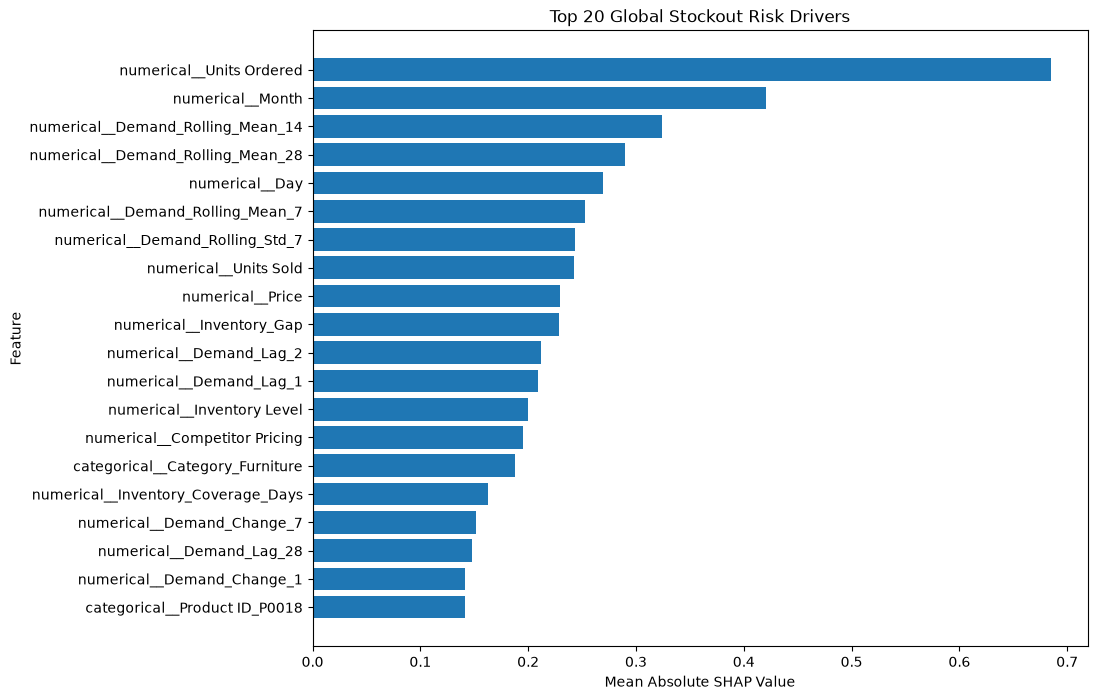

In [31]:
top_shap = (
    shap_importance
    .head(20)
    .sort_values(
        "Mean_Absolute_SHAP"
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_shap["Feature"],
    top_shap["Mean_Absolute_SHAP"]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel("Feature")

plt.title(
    "Top 20 Global Stockout Risk Drivers"
)

plt.show()

### Step 28 — Create SHAP Summary Plot
Why

The summary plot shows both importance and direction of the feature's effect.

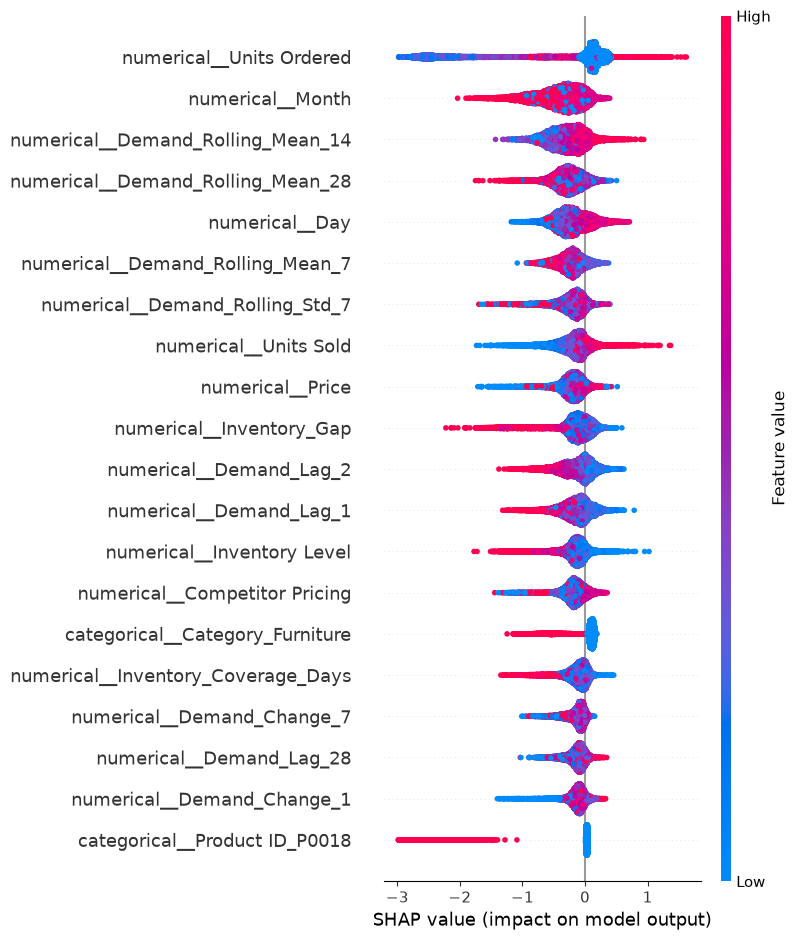

In [32]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names,
    max_display=20
)

### Step 29 — Create SHAP Bar Summary
Why

The bar summary gives a cleaner presentation of overall feature importance.

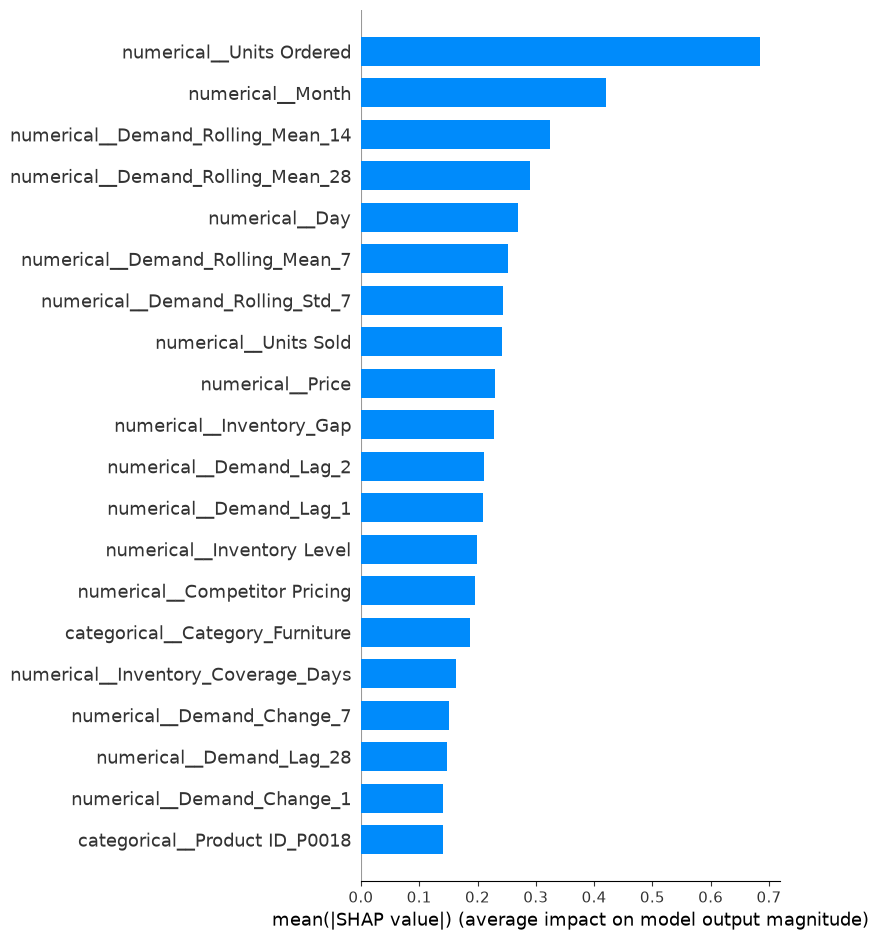

In [33]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20
)

### Step 30 — Analyze Inventory Features
Why

Inventory-related variables should be particularly important for explaining stockout risk.

In [34]:
inventory_shap_features = [
    feature
    for feature in feature_names
    if (
        "Inventory" in feature or
        "Demand" in feature or
        "Units" in feature
    )
]

inventory_shap_importance = (
    shap_importance[
        shap_importance["Feature"]
        .isin(inventory_shap_features)
    ]
)

display(
    inventory_shap_importance
    .head(20)
)

,Feature,Mean_Absolute_SHAP
0,numerical__Units Ordered,0.684622
2,numerical__Demand_Rolling_Mean_14,0.324146
3,numerical__Demand_Rolling_Mean_28,0.289949
5,numerical__Demand_Rolling_Mean_7,0.252928
6,numerical__Demand_Rolling_Std_7,0.243279
7,numerical__Units Sold,0.242406
9,numerical__Inventory_Gap,0.228405
10,numerical__Demand_Lag_2,0.211873
11,numerical__Demand_Lag_1,0.209395
12,numerical__Inventory Level,0.199837


### Step 31 — Select One High-Risk Product
Why

We need one real prediction to demonstrate local explainability.

In [35]:
test_prediction_df = df_model.loc[
    test_mask,
    [
        "Date",
        "Store ID",
        "Product ID",
        "Category",
        "Region",
        "Inventory Level",
        "Units Sold",
        "Units Ordered",
        "Demand_Lag_1",
        "Demand_Rolling_Mean_7",
        "Inventory_Coverage_Days",
        target
    ]
].copy()

test_prediction_df[
    "Stockout_Probability"
] = xgb_test_proba

test_prediction_df[
    "Predicted_Stockout"
] = xgb_test_pred

test_prediction_df = (
    test_prediction_df
    .sort_values(
        "Stockout_Probability",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    test_prediction_df.head(10)
)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand_Lag_1,Demand_Rolling_Mean_7,Inventory_Coverage_Days,stockout_next_7_days,Stockout_Probability,Predicted_Stockout
0,2023-11-25,S004,P0016,Furniture,West,170,87,234,36.0,75.571429,2.249527,0,0.846082,1
1,2024-01-12,S005,P0009,Groceries,North,136,136,764,115.0,84.285714,1.613559,0,0.839340,1
2,2023-09-23,S004,P0002,Groceries,West,254,242,488,101.0,100.285714,2.532764,0,0.807737,1
3,2023-12-25,S001,P0006,Toys,North,149,67,366,72.0,91.285714,1.632238,0,0.803426,1
4,2024-01-12,S005,P0015,Groceries,North,221,189,412,109.0,78.285714,2.822993,0,0.802900,1
5,2023-09-19,S005,P0016,Toys,North,584,130,0,105.0,114.142857,5.116395,0,0.788939,1
6,2023-09-28,S004,P0016,Furniture,West,110,103,292,62.0,77.285714,1.423290,0,0.783365,1
7,2023-10-15,S003,P0015,Groceries,East,325,154,722,82.0,104.000000,3.125000,0,0.773043,1
8,2023-09-22,S005,P0016,Toys,North,264,94,327,79.0,104.285714,2.531507,0,0.769643,1
9,2023-10-24,S005,P0009,Groceries,North,446,38,0,78.0,99.142857,4.498559,0,0.756334,1


### Step 32 — Select Highest-Risk Record

In [36]:
highest_risk_index = (
    test_prediction_df
    .index[0]
)

highest_risk_record = (
    test_prediction_df
    .iloc[0]
)

print(
    "Highest-risk product:"
)

display(
    highest_risk_record.to_frame()
)

Highest-risk product:


,0
Date,2023-11-25 00:00:00
Store ID,S004
Product ID,P0016
Category,Furniture
Region,West
Inventory Level,170
Units Sold,87
Units Ordered,234
Demand_Lag_1,36.0
Demand_Rolling_Mean_7,75.571429


### Step 33 — Find SHAP Explanation for Highest-Risk Record
Why

We want to understand exactly which features caused this specific product to receive a high risk score.

In [37]:
highest_risk_original_index = (
    X_test.index[
        np.argmax(xgb_test_proba)
    ]
)

highest_risk_position = (
    X_test.index
    .get_loc(
        highest_risk_original_index
    )
)

print(
    "Original dataframe index:",
    highest_risk_original_index
)

print(
    "SHAP row position:",
    highest_risk_position
)

Original dataframe index: 57693
SHAP row position: 11105


### Step 34 — Extract Local SHAP Values

In [39]:
local_shap_values = (
    shap_values[
        highest_risk_position
    ]
)

local_explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": local_shap_values,
    "Absolute_SHAP": np.abs(
        local_shap_values
    )
})

local_explanation = (
    local_explanation
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    local_explanation.head(20)
)

,Feature,SHAP_Value,Absolute_SHAP
0,numerical__Units Ordered,-0.453434,0.453434
1,numerical__Demand_Lag_1,0.399030,0.399030
2,categorical__Product ID_P0016,0.374417,0.374417
3,numerical__Day,0.326112,0.326112
4,numerical__Price,0.241409,0.241409
5,numerical__Demand_Rolling_Mean_14,-0.197379,0.197379
6,numerical__Demand_Rolling_Mean_7,0.187431,0.187431
7,numerical__Inventory_Gap,0.174114,0.174114
8,categorical__Seasonality_Spring,0.159022,0.159022
9,categorical__Store ID_S004,-0.155038,0.155038


### Step 35 — Separate Risk-Increasing Features
Why

These are the features pushing the selected product toward stockout.

In [40]:
risk_increasing = (
    local_explanation[
        local_explanation["SHAP_Value"] > 0
    ]
    .sort_values(
        "SHAP_Value",
        ascending=False
    )
)

display(
    risk_increasing.head(10)
)

,Feature,SHAP_Value,Absolute_SHAP
1,numerical__Demand_Lag_1,0.399030,0.399030
2,categorical__Product ID_P0016,0.374417,0.374417
3,numerical__Day,0.326112,0.326112
4,numerical__Price,0.241409,0.241409
6,numerical__Demand_Rolling_Mean_7,0.187431,0.187431
7,numerical__Inventory_Gap,0.174114,0.174114
8,categorical__Seasonality_Spring,0.159022,0.159022
11,numerical__Inventory_Coverage_Days,0.143817,0.143817
14,numerical__Demand_Lag_2,0.085630,0.085630
18,categorical__Store ID_S001,0.066311,0.066311


### Step 36 — Separate Risk-Reducing Features
Why

These are features pushing the prediction away from stockout.

In [41]:
risk_reducing = (
    local_explanation[
        local_explanation["SHAP_Value"] < 0
    ]
    .sort_values(
        "SHAP_Value"
    )
)

display(
    risk_reducing.head(10)
)

,Feature,SHAP_Value,Absolute_SHAP
0,numerical__Units Ordered,-0.453434,0.453434
5,numerical__Demand_Rolling_Mean_14,-0.197379,0.197379
9,categorical__Store ID_S004,-0.155038,0.155038
10,numerical__Price_Difference,-0.152473,0.152473
12,numerical__Month,-0.108852,0.108852
13,numerical__Demand_Change_1,-0.101075,0.101075
15,numerical__Demand_Change_7,-0.084222,0.084222
16,numerical__Demand_Lag_14,-0.074612,0.074612
17,numerical__Demand_Rolling_Mean_28,-0.073978,0.073978
19,numerical__Demand_Lag_7,-0.065838,0.065838


### Step 37 — Plot Local Feature Contributions
Why

This provides a visual explanation of one individual stockout prediction.

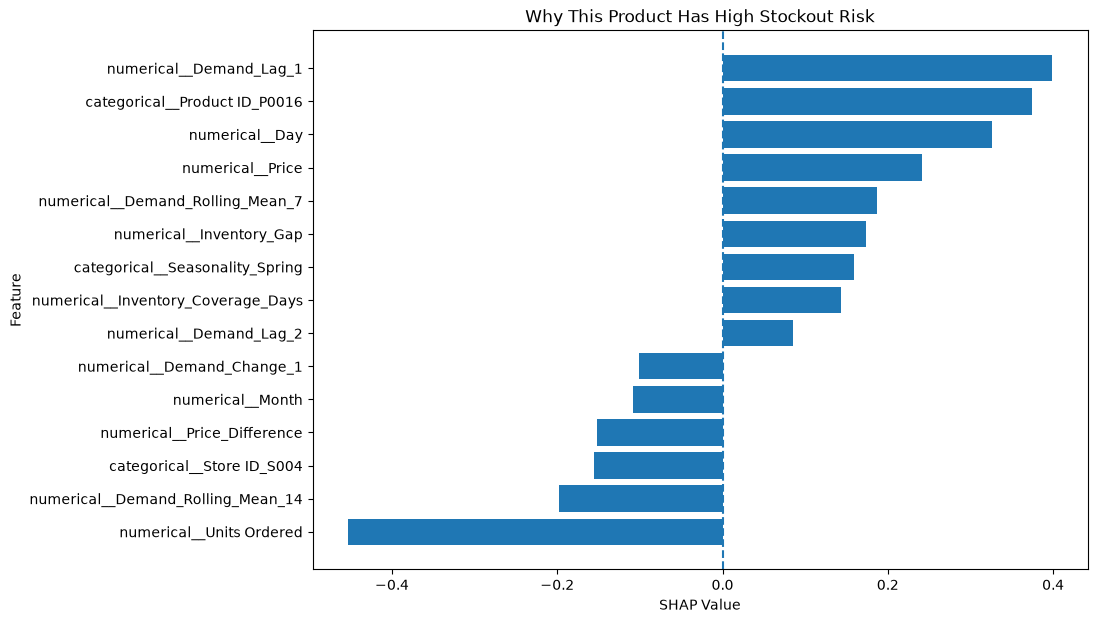

In [42]:
local_top = (
    local_explanation
    .head(15)
    .sort_values(
        "SHAP_Value"
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    local_top["Feature"],
    local_top["SHAP_Value"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")

plt.title(
    "Why This Product Has High Stockout Risk"
)

plt.show()

### Step 38 — Create SHAP Waterfall Explanation
Why

The waterfall plot provides a detailed explanation of how individual features move the prediction from the model's baseline toward the final risk score.

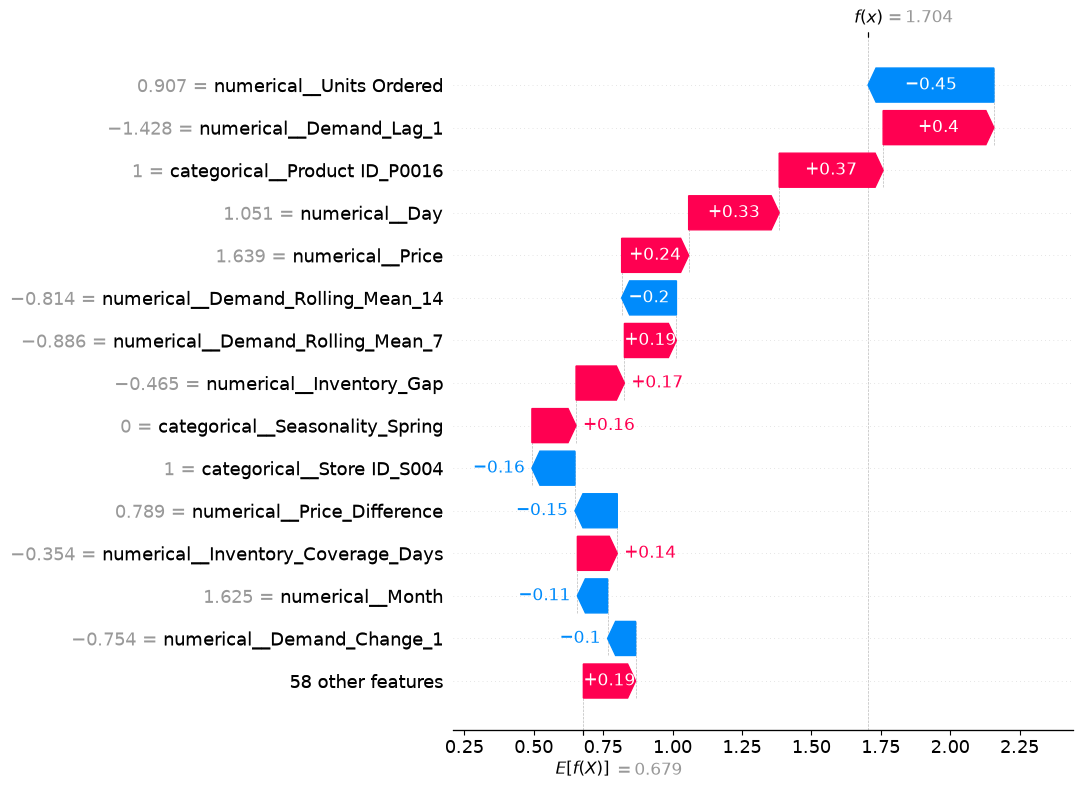

In [43]:
shap_explanation = shap.Explanation(
    values=local_shap_values,
    base_values=explainer.expected_value,
    data=X_test_shap[
        highest_risk_position
    ],
    feature_names=feature_names
)

shap.plots.waterfall(
    shap_explanation,
    max_display=15
)

### Step 39 — Generate Business-Friendly Feature Values
Why

SHAP gives mathematical explanations, but RetailIQ will eventually need readable business explanations.

In [44]:
business_record = df_model.loc[
    highest_risk_original_index,
    stockout_features
]

business_values = pd.DataFrame({
    "Feature": stockout_features,
    "Value": [
        business_record[feature]
        for feature in stockout_features
    ]
})

display(
    business_values
)

,Feature,Value
0,Store ID,S004
1,Product ID,P0016
2,Category,Furniture
3,Region,West
4,Weather Condition,Rainy
5,Seasonality,Autumn
6,Year,2023
7,Month,11
8,Quarter,4
9,Day,25


### Step 40 — Create Risk Explanation Dataset
Why

This creates structured information that the future GenAI layer can turn into natural-language explanations.

In [45]:
top_risk_drivers = (
    risk_increasing
    .head(5)
    .copy()
)

top_risk_drivers["Risk_Direction"] = (
    "Increases Stockout Risk"
)

display(
    top_risk_drivers
)

,Feature,SHAP_Value,Absolute_SHAP,Risk_Direction
1,numerical__Demand_Lag_1,0.399030,0.399030,Increases Stockout Risk
2,categorical__Product ID_P0016,0.374417,0.374417,Increases Stockout Risk
3,numerical__Day,0.326112,0.326112,Increases Stockout Risk
4,numerical__Price,0.241409,0.241409,Increases Stockout Risk
6,numerical__Demand_Rolling_Mean_7,0.187431,0.187431,Increases Stockout Risk


### Step 41 — Create Product-Level Explanation Table
Why

We want a reusable table containing risk, inventory context, and major SHAP drivers.

In [46]:
product_explanation = (
    test_prediction_df
    .copy()
)

product_explanation[
    "Risk_Level"
] = pd.cut(
    product_explanation[
        "Stockout_Probability"
    ],
    bins=[
        -np.inf,
        0.20,
        0.50,
        0.75,
        np.inf
    ],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

display(
    product_explanation.head(20)
)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand_Lag_1,Demand_Rolling_Mean_7,Inventory_Coverage_Days,stockout_next_7_days,Stockout_Probability,Predicted_Stockout,Risk_Level
0,2023-11-25,S004,P0016,Furniture,West,170,87,234,36.0,75.571429,2.249527,0,0.846082,1,Very High
1,2024-01-12,S005,P0009,Groceries,North,136,136,764,115.0,84.285714,1.613559,0,0.839340,1,Very High
2,2023-09-23,S004,P0002,Groceries,West,254,242,488,101.0,100.285714,2.532764,0,0.807737,1,Very High
3,2023-12-25,S001,P0006,Toys,North,149,67,366,72.0,91.285714,1.632238,0,0.803426,1,Very High
4,2024-01-12,S005,P0015,Groceries,North,221,189,412,109.0,78.285714,2.822993,0,0.802900,1,Very High
5,2023-09-19,S005,P0016,Toys,North,584,130,0,105.0,114.142857,5.116395,0,0.788939,1,Very High
6,2023-09-28,S004,P0016,Furniture,West,110,103,292,62.0,77.285714,1.423290,0,0.783365,1,Very High
7,2023-10-15,S003,P0015,Groceries,East,325,154,722,82.0,104.000000,3.125000,0,0.773043,1,Very High
8,2023-09-22,S005,P0016,Toys,North,264,94,327,79.0,104.285714,2.531507,0,0.769643,1,Very High
9,2023-10-24,S005,P0009,Groceries,North,446,38,0,78.0,99.142857,4.498559,0,0.756334,1,Very High


### Step 42 — Count Risk Levels
Why

This tells us how many future products fall into each RetailIQ risk category.

In [47]:
risk_distribution = (
    product_explanation[
        "Risk_Level"
    ]
    .value_counts()
    .sort_index()
)

print(
    risk_distribution
)

Risk_Level
Low          13920
Moderate       671
High            99
Very High       10
Name: count, dtype: int64


### Step 43 — Create Global Risk Driver Table

In [48]:
global_risk_drivers = (
    shap_importance
    .head(20)
    .copy()
)

global_risk_drivers[
    "Rank"
] = np.arange(
    1,
    len(global_risk_drivers) + 1
)

global_risk_drivers = (
    global_risk_drivers[
        [
            "Rank",
            "Feature",
            "Mean_Absolute_SHAP"
        ]
    ]
)

display(
    global_risk_drivers
)

,Rank,Feature,Mean_Absolute_SHAP
0,1,numerical__Units Ordered,0.684622
1,2,numerical__Month,0.420153
2,3,numerical__Demand_Rolling_Mean_14,0.324146
3,4,numerical__Demand_Rolling_Mean_28,0.289949
4,5,numerical__Day,0.268985
5,6,numerical__Demand_Rolling_Mean_7,0.252928
6,7,numerical__Demand_Rolling_Std_7,0.243279
7,8,numerical__Units Sold,0.242406
8,9,numerical__Price,0.229258
9,10,numerical__Inventory_Gap,0.228405


### Step 44 — Save SHAP Global Importance
Why

The global explanations will later be used in the dashboard and project documentation.

In [49]:
shap_importance.to_csv(
    "../data/processed/stockout_shap_importance.csv",
    index=False
)

print(
    "Saved:",
    "../data/processed/stockout_shap_importance.csv"
)

Saved: ../data/processed/stockout_shap_importance.csv


### Step 45 — Save Local Explanation

In [50]:
local_explanation.to_csv(
    "../data/processed/stockout_local_explanation.csv",
    index=False
)

print(
    "Saved:",
    "../data/processed/stockout_local_explanation.csv"
)

Saved: ../data/processed/stockout_local_explanation.csv


### Step 46 — Save Product Risk Explanation

In [51]:
product_explanation.to_csv(
    "../data/processed/stockout_product_explanations.csv",
    index=False
)

print(
    "Saved:",
    "../data/processed/stockout_product_explanations.csv"
)

Saved: ../data/processed/stockout_product_explanations.csv


### Step 47 — Save Global Risk Drivers

In [52]:
global_risk_drivers.to_csv(
    "../data/processed/stockout_global_risk_drivers.csv",
    index=False
)

print(
    "Saved:",
    "../data/processed/stockout_global_risk_drivers.csv"
)

Saved: ../data/processed/stockout_global_risk_drivers.csv


### Step 48 — Save the Explainable XGBoost Model
Why

Later API/GenAI components can reuse the trained model instead of retraining it every time.

In [53]:
joblib.dump(
    xgb_model,
    "../data/processed/stockout_xgb_explainable_model.joblib"
)

print(
    "Saved:",
    "../data/processed/stockout_xgb_explainable_model.joblib"
)

Saved: ../data/processed/stockout_xgb_explainable_model.joblib


### Step 49 — Final Notebook 07 Summary

In [54]:
print("=" * 75)
print("RETAILIQ — NOTEBOOK 07 MODEL EXPLAINABILITY")
print("=" * 75)

print("\nModel:")
print("XGBoost Stockout Prediction")

print("\nTest Records:")
print(len(X_test))

print("\nStockout Predictions:")
print(xgb_test_pred.sum())

print("\nMean Stockout Probability:")
print(
    round(
        xgb_test_proba.mean(),
        4
    )
)

print("\nModel Performance:")
print(
    "Precision:",
    round(precision, 4)
)

print(
    "Recall:",
    round(recall, 4)
)

print(
    "F1:",
    round(f1, 4)
)

print(
    "ROC-AUC:",
    round(roc_auc, 4)
)

print(
    "PR-AUC:",
    round(pr_auc, 4)
)

print("\nTop 10 Global Risk Drivers:")
display(
    global_risk_drivers.head(10)
)

print("\nRisk Level Distribution:")
print(
    risk_distribution
)

print("\nSaved Files:")
print(
    "- stockout_shap_importance.csv"
)

print(
    "- stockout_local_explanation.csv"
)

print(
    "- stockout_product_explanations.csv"
)

print(
    "- stockout_global_risk_drivers.csv"
)

print(
    "- stockout_xgb_explainable_model.joblib"
)

RETAILIQ — NOTEBOOK 07 MODEL EXPLAINABILITY

Model:
XGBoost Stockout Prediction

Test Records:
14700

Stockout Predictions:
780

Mean Stockout Probability:
0.0429

Model Performance:
Precision: 0.1051
Recall: 0.167
F1: 0.129
ROC-AUC: 0.7466
PR-AUC: 0.0842

Top 10 Global Risk Drivers:


,Rank,Feature,Mean_Absolute_SHAP
0,1,numerical__Units Ordered,0.684622
1,2,numerical__Month,0.420153
2,3,numerical__Demand_Rolling_Mean_14,0.324146
3,4,numerical__Demand_Rolling_Mean_28,0.289949
4,5,numerical__Day,0.268985
5,6,numerical__Demand_Rolling_Mean_7,0.252928
6,7,numerical__Demand_Rolling_Std_7,0.243279
7,8,numerical__Units Sold,0.242406
8,9,numerical__Price,0.229258
9,10,numerical__Inventory_Gap,0.228405



Risk Level Distribution:
Risk_Level
Low          13920
Moderate       671
High            99
Very High       10
Name: count, dtype: int64

Saved Files:
- stockout_shap_importance.csv
- stockout_local_explanation.csv
- stockout_product_explanations.csv
- stockout_global_risk_drivers.csv
- stockout_xgb_explainable_model.joblib
